# Lab 7: LSTM

This notebook contains the expected solutions for Lab 7 on LSTM (Long Short-Term Memory).

## Objective
By the end of this lab, you will be able to train a simple LSTM, and its evaluate performance and make predictions for sequential data (e.g., time series).

## Lab Task. LSTM Traning and Prediction

Train a minimal LSTM to predict the next value of a noisy sine wave given the previous 20 values. By the end you will have built a working sequence model from scratch and plotted its predictions.

Use the following snippet below to generate your dataset (discusseed in the lecture).

In [1]:
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data
t = np.linspace(0, 100, 1000)
signal = np.sin(t) + 0.1 * np.random.randn(1000)

# 2. Sliding window (seq_len=20, predict next step)
def make_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return torch.tensor(X, dtype=torch.float32).unsqueeze(-1), \
           torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

X, y = make_sequences(signal)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

/tmp/ipykernel_25290/2232746310.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(X, dtype=torch.float32).unsqueeze(-1), \


### Task 1. Define the model

Complete the class below. Use nn.LSTM with input_size=1, hidden_size=32, batch_first=True, and a single linear layer to produce one output value.

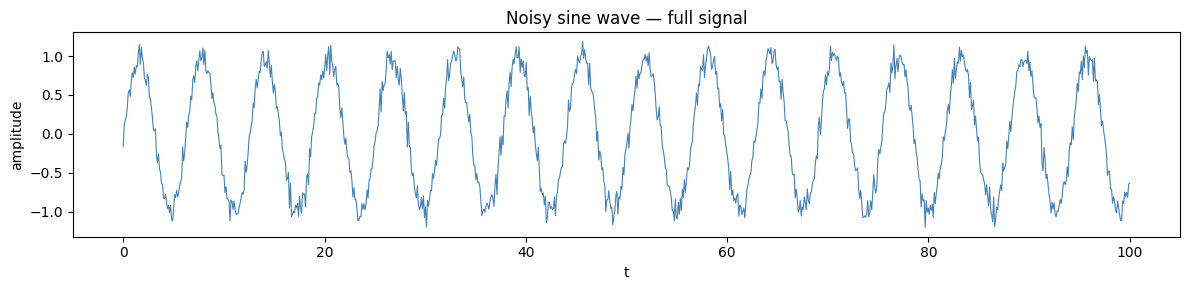

LSTMPredictor(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Total trainable parameters: 4,513


In [5]:
# Visualise the data
plt.figure(figsize=(12, 3))
plt.plot(t, signal, linewidth=0.8, color='steelblue')
plt.title('Noisy sine wave — full signal')
plt.xlabel('t')
plt.ylabel('amplitude')
plt.tight_layout()
plt.show()

# Define the class
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, 1, batch_first=True) 
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        
        h = torch.zeros((1, x.shape[0], self.hidden_size))
        c = torch.zeros((1, x.shape[0], self.hidden_size))
        out, (hn, cn) = self.lstm(x, (h, c))
        return self.fc(out[:, -1, :]) # use last time step

# Complete the missing code parts
model = LSTMPredictor()
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

### Task 2 Train for 10 epochs ~10 min

Use nn.MSELoss() and Adam(lr=1e-3). Loop over the full training set each epoch (no DataLoader needed — use the full tensors). Print the loss each epoch.


Epoch  1 | Train MSE: 0.48387
Epoch  2 | Train MSE: 0.47672
Epoch  3 | Train MSE: 0.46951
Epoch  4 | Train MSE: 0.46223
Epoch  5 | Train MSE: 0.45489
Epoch  6 | Train MSE: 0.44746
Epoch  7 | Train MSE: 0.43993
Epoch  8 | Train MSE: 0.43228
Epoch  9 | Train MSE: 0.42450
Epoch 10 | Train MSE: 0.41657
Epoch 11 | Train MSE: 0.40848
Epoch 12 | Train MSE: 0.40020
Epoch 13 | Train MSE: 0.39172
Epoch 14 | Train MSE: 0.38303
Epoch 15 | Train MSE: 0.37410
Epoch 16 | Train MSE: 0.36491
Epoch 17 | Train MSE: 0.35547
Epoch 18 | Train MSE: 0.34575
Epoch 19 | Train MSE: 0.33575
Epoch 20 | Train MSE: 0.32549
Epoch 21 | Train MSE: 0.31496
Epoch 22 | Train MSE: 0.30420
Epoch 23 | Train MSE: 0.29326
Epoch 24 | Train MSE: 0.28220
Epoch 25 | Train MSE: 0.27112
Epoch 26 | Train MSE: 0.26015
Epoch 27 | Train MSE: 0.24946
Epoch 28 | Train MSE: 0.23923
Epoch 29 | Train MSE: 0.22969
Epoch 30 | Train MSE: 0.22103
Epoch 31 | Train MSE: 0.21340
Epoch 32 | Train MSE: 0.20683
Epoch 33 | Train MSE: 0.20122
Epoch 34 |

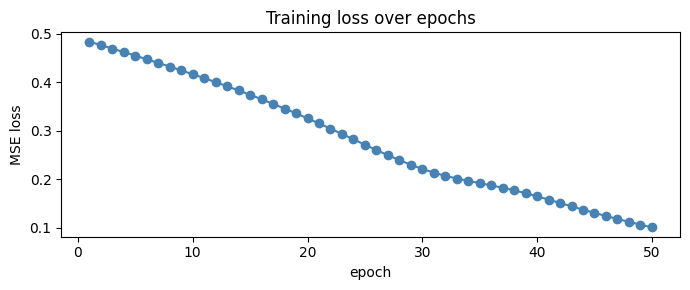

In [9]:
# Complete missing code parts
# MSE loss and optimiser Adam
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(lr=1e-3, params=model.parameters())

train_losses = []

for epoch in range(1, 51):
    model.train()
    optimiser.zero_grad()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimiser.step()
    train_losses.append(loss.item())
    print(f"Epoch {epoch:2d} | Train MSE: {loss.item():.5f}")

# Plot training loss
plt.figure(figsize=(7, 3))
plt.plot(range(1, 51), train_losses, marker='o', color='steelblue')
plt.title('Training loss over epochs')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.tight_layout()
plt.show()


### Task 3. Evaluate and plot

Run inference on X_test (remember model.eval() and torch.no_grad()). Plot the ground truth and predicted values on the same axes.

Note: We switch to model.eval() and wrap inference in torch.no_grad() to disable gradient tracking (faster and uses less memory).

Test MAE: 0.2621


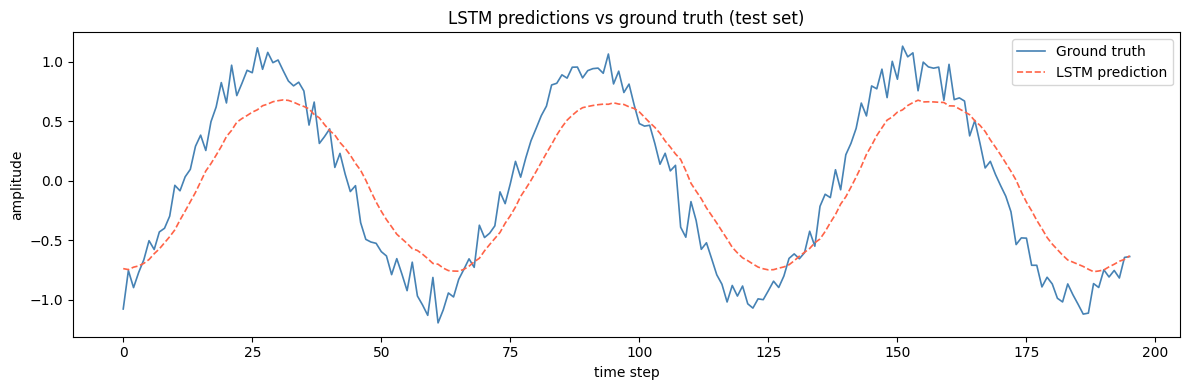

In [10]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)

# Convert to numpy for plotting
y_pred_np  = y_pred.squeeze().numpy()
y_test_np  = y_test.squeeze().numpy()

# Compute the mean absolute error (MAE)
mae = np.mean(np.abs(y_pred_np - y_test_np))
print(f"Test MAE: {mae:.4f}")

# Plot
plt.figure(figsize=(12, 4))
plt.plot(y_test_np,  label='Ground truth', linewidth=1.2, color='steelblue')
plt.plot(y_pred_np, label='LSTM prediction', linewidth=1.2,
         color='tomato', linestyle='--')
plt.title('LSTM predictions vs ground truth (test set)')
plt.xlabel('time step')
plt.ylabel('amplitude')
plt.legend()
plt.tight_layout()
plt.show()


### Task 4. Reflection: what happens with hidden_size=2?

hidden_size=32 -> Test MAE: 0.2621
hidden_size=2  -> Test MAE: 0.6247


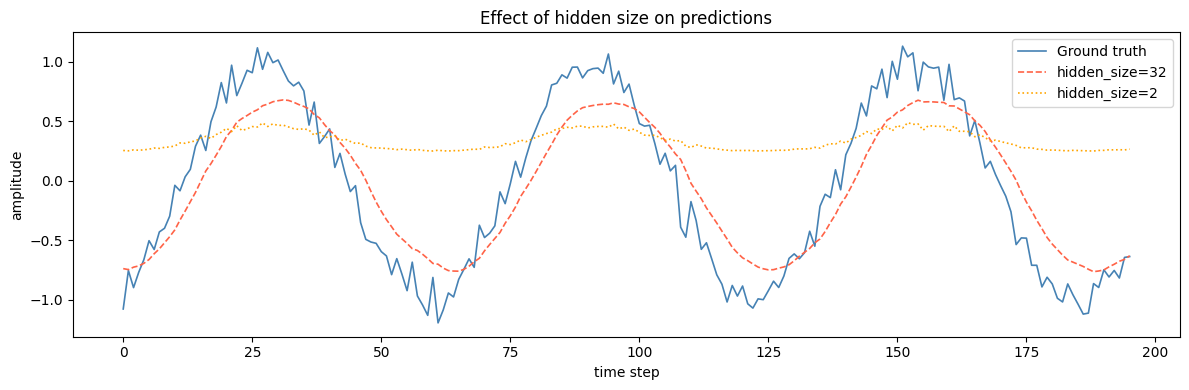

In [12]:
# Retrain with a tiny hidden size
small_model = LSTMPredictor(input_size=1, hidden_size=2)
small_opt   = torch.optim.Adam(small_model.parameters(), lr=1e-3)

for epoch in range(1, 51):
    small_model.train()
    small_opt.zero_grad()
    preds = small_model(X_train)
    loss  = criterion(preds, y_train)
    loss.backward()
    small_opt.step()

small_model.eval()
with torch.no_grad():
    y_small = small_model(X_test).squeeze().numpy()

mae_small = np.mean(np.abs(y_small - y_test_np))
print(f"hidden_size=32 -> Test MAE: {mae:.4f}")
print(f"hidden_size=2  -> Test MAE: {mae_small:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(y_test_np,  label='Ground truth',    linewidth=1.2, color='steelblue')
plt.plot(y_pred_np,  label='hidden_size=32',  linewidth=1.2, color='tomato',  linestyle='--')
plt.plot(y_small,    label='hidden_size=2',   linewidth=1.2, color='orange',  linestyle=':')
plt.title('Effect of hidden size on predictions')
plt.xlabel('time step')
plt.ylabel('amplitude')
plt.legend()
plt.tight_layout()
plt.show()

### Reflection answer



Your answer: 